# Graph-state closure versus hold-last

This notebook shows opt-in graph-state dynamics: a topology head can
propose $\hat A_{t+1}$ and feed it into the networked Koopman step,
instead of copying the last observed edges (hold-last). On a seeded
six-node cycle replaced by a directed $G(n,p)$ draw (independent
Bernoulli arcs, $p=0.35$), a dense stub that scores the **true next
graph** beats hold-last when the comparison target is the model's own
one-step oracle forecast.

**Honesty.** That comparison is a **wiring check**, not a learned-forecast
claim and not a traffic or METR-LA result. Default
`graph_dynamics=None` keeps the 0.14 hold-last schedule. The configured
default head is `sparse_candidate` (at most `candidate_k` destinations
per node); this demo uses `dense_mlp` only so the stub can score every
pair. Predicted edges enter $K_{\mathrm{eff}}$ as sigmoid weights on the
candidate COO, not a hard threshold. Homogeneous models only.


## Setup

Imports, a six-node bidirectional cycle / directed $G(n,p)$ helper
pair, and a tiny `koopman="graph"` model. Feature coordinates are
dimensionless synthetic values. Written against the in-repo
`koopman_graph` checkout.


In [1]:
import os
import types
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import (
    GraphDynamicsConfig,
    GraphSnapshotSequence,
    graph_state_at,
)
from koopman_graph.nn.predicted_topology import PredictedTopologyHead

print("koopman_graph", koopman_graph.__version__)

SEED = 6
N = 6
IN_CHANNELS = 2
LATENT_DIM = 2


def cycle_edge_index(num_nodes: int) -> torch.Tensor:
    forward_src = list(range(num_nodes))
    forward_dst = list(range(1, num_nodes)) + [0]
    src = forward_src + forward_dst
    dst = forward_dst + forward_src
    return torch.tensor([src, dst], dtype=torch.long)


def directed_gnp_edge_index(num_nodes: int, *, seed: int) -> torch.Tensor:
    # Directed G(n,p): independent Bernoulli arcs; not undirected ER.
    generator = torch.Generator().manual_seed(seed)
    mask = torch.rand(num_nodes, num_nodes, generator=generator) < 0.35
    mask.fill_diagonal_(False)
    src, dst = mask.nonzero(as_tuple=True)
    if src.numel() == 0:
        src = torch.arange(num_nodes)
        dst = (src + 1) % num_nodes
    return torch.stack([src, dst], dim=0)


def tiny_model(config: GraphDynamicsConfig | None) -> GraphKoopmanModel:
    return GraphKoopmanModel(
        GNNEncoder(IN_CHANNELS, 8, LATENT_DIM, num_layers=1),
        GNNDecoder(LATENT_DIM, 8, IN_CHANNELS, num_layers=1),
        latent_dim=LATENT_DIM,
        time_step=0.1,
        koopman="graph",
        graph_dynamics=config,
    )


koopman_graph 0.15.0


## Motivation and background

Mechanical dynamic topology (notebook 18) already lets each snapshot
carry its own `edge_index`. The forecast loop still **held the last
observed graph** unless the caller passed `future_topologies`. That is
the right control when the next adjacency is known, and the wrong
default when the scientific question is whether the model can propose
$\hat A_{t+1}$ after a structural event.

`GraphDynamicsConfig` (opt-in; off the root façade) attaches a topology
head. Recursive rollout uses predicted $\hat A_{t+1}=g_\phi(z_t)$ when
`future_topologies` is omitted. Hold-last and oracle futures remain
controls. This is distinct from static Graph WaveNet
`learn_topology="self_adaptive"` / `AdaptiveAdjacency` (Wu et al.,
IJCAI 2019; `Wu2019WaveNet`); combining that path with a non-`none`
topology head raises.

A changing node **universe** is a different problem: sequences still
lock $N$ unless the caller applies `EntityRemap` into a finite $N_{\max}$.
This notebook keeps $N$ fixed. Unbounded growth is refused.


## Minimal example

Attach the default sparse-candidate config, wrap two snapshots, and
compare recursive versus hold-last `predict`. The two rollouts should
differ once a head is attached. `graph_state_at` is a supervision
record, not a replacement for `GraphSnapshotSequence`.


In [2]:
torch.manual_seed(SEED)
config = GraphDynamicsConfig()  # sparse_candidate, candidate_k=8
print("topology_head", config.topology_head, "candidate_k", config.candidate_k)

g0 = cycle_edge_index(N)
g1 = directed_gnp_edge_index(N, seed=11)
snapshots = [
    Data(x=torch.randn(N, IN_CHANNELS), edge_index=g0),
    Data(x=torch.randn(N, IN_CHANNELS), edge_index=g1),
]
sequence = GraphSnapshotSequence(snapshots, allow_dynamic_topology=True)
state = graph_state_at(sequence, 0)
print("graph_state_at x", tuple(state.x.shape), "E", int(state.edge_index.shape[1]))

model = tiny_model(config)
origin = snapshots[0]
model.eval()
with torch.no_grad():
    recursive = model.predict(origin, steps=1, topology_policy="recursive")[0]
    hold = model.predict(origin, steps=1, topology_policy="hold_last")[0]
print("recursive uses predicted weights:", recursive.edge_weight is not None)
print("hold-last copies origin edges:", bool(torch.equal(hold.edge_index, origin.edge_index)))
print("node-feature tensors differ:", not torch.allclose(recursive.x, hold.x, atol=1e-6))


topology_head sparse_candidate candidate_k 8
graph_state_at x (6, 2) E 12
recursive uses predicted weights: True
hold-last copies origin edges: True
node-feature tensors differ: True


## Progressive deep dive

The seed-11 check is not "a randomly initialized head forecasts better."
Truth is the **same model** advanced one step with oracle
`future_topologies` equal to the post-event directed $G(n,p)$ graph.
Hold-last keeps the pre-event cycle. A dense stub that assigns large
logits to the true next arcs should land closer to that oracle than
hold-last, but not at zero error: recursive rollout still feeds
$\sigma(\mathrm{logit})$ on all $N(N-1)$ off-diagonal pairs, whereas
the oracle COO is unweighted.

We bind `pairwise_logits` on `PredictedTopologyHead` (`dense_mlp`) to
that stub. Mean squared error (MSE) is over node features
(dimensionless synthetic coordinates).


In [3]:
torch.manual_seed(SEED)
g0 = cycle_edge_index(N)
g1 = directed_gnp_edge_index(N, seed=11)
origin = Data(x=torch.randn(N, IN_CHANNELS), edge_index=g0)
nxt = Data(x=torch.zeros(N, IN_CHANNELS), edge_index=g1)

model = tiny_model(GraphDynamicsConfig(topology_head="dense_mlp"))
assert isinstance(model.predicted_topology, PredictedTopologyHead)


def oracle_logits(self: PredictedTopologyHead, z: torch.Tensor) -> torch.Tensor:
    del self
    logits = torch.full((z.shape[0], z.shape[0]), -8.0, device=z.device, dtype=z.dtype)
    logits[g1[0], g1[1]] = 8.0
    logits.fill_diagonal_(-1e9)
    return logits


model.predicted_topology.pairwise_logits = types.MethodType(
    oracle_logits,
    model.predicted_topology,
)
model.eval()
with torch.no_grad():
    truth = model.predict(origin, steps=1, future_topologies=[nxt])[0]
    recursive = model.predict(origin, steps=1, topology_policy="recursive")[0]
    hold = model.predict(origin, steps=1, topology_policy="hold_last")[0]

mse_rec = float(nn.functional.mse_loss(recursive.x, truth.x))
mse_hold = float(nn.functional.mse_loss(hold.x, truth.x))
print(f"stub recursive MSE vs oracle: {mse_rec:.6f}")
print(f"hold-last MSE vs oracle:      {mse_hold:.6f}")
if not (mse_rec < mse_hold):
    raise AssertionError(
        f"stub recursive MSE {mse_rec} was not below hold-last {mse_hold}"
    )
print("stub recursive beats hold-last on the oracle one-step (wiring check).")


stub recursive MSE vs oracle: 0.001610
hold-last MSE vs oracle:      0.070864
stub recursive beats hold-last on the oracle one-step (wiring check).


Dense pairwise logits must **permute with nodes**. If $P$ permutes
rows of $z$, then $\mathrm{logits}(Pz) = P\,\mathrm{logits}(z)\,P^{\top}$.
That is not entity resolution: a changing node count still requires a
user-supplied injective `EntityRemap` into a finite $N_{\max}$. Silent
universe merge and unbounded growth remain refused.


In [4]:
torch.manual_seed(5)
head = PredictedTopologyHead(LATENT_DIM, hidden_dim=8, max_nodes=8)
z = torch.randn(N, LATENT_DIM)
perm = torch.tensor([2, 0, 4, 1, 3, 5])
logits = head.pairwise_logits(z)
logits_perm = head.pairwise_logits(z[perm])
torch.testing.assert_close(logits_perm, logits[perm][:, perm], atol=1e-5, rtol=0.0)
print("dense logits permute with the node order (atol=1e-5).")
print("EntityRemap is still required if N changes; this demo keeps N fixed.")


dense logits permute with the node order (atol=1e-5).
EntityRemap is still required if N changes; this demo keeps N fixed.


## Results

The bar chart repeats the two MSE values from the stub comparison. The
prints under it report the COO sizes behind the leftover stub error.

Look at two quantities. First, the gap: hold-last is the pre-event
cycle, so it cannot match an oracle that already uses the post-event
arcs. Second, the stub MSE is small but not zero. Recursive decode
keeps every off-diagonal pair with sigmoid weights
$\sigma(8)\approx 0.9997$ and $\sigma(-8)\approx 3.4\times 10^{-4}$
on a dense COO of size $N(N-1)=30$. The oracle one-step uses the
unweighted directed $G(n,p)$ graph (`edge_weight` omitted). That
residual is the sigmoid mechanism, not a failed wiring check, and it
does **not** show that a trained GNN encoder learned the event.


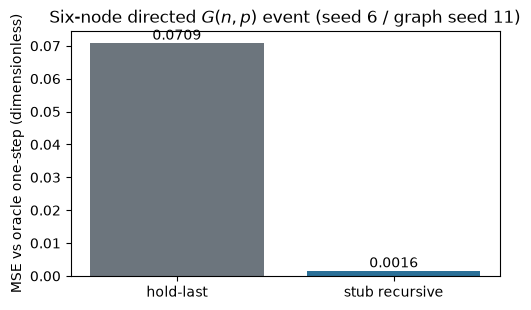

hold-last MSE 0.070864 stub MSE 0.001610
oracle COO E 8 edge_weight None
recursive COO E 30 N*(N-1) 30
recursive sigmoid min/max 0.000335 0.999665


In [5]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
labels = ["hold-last", "stub recursive"]
values = [mse_hold, mse_rec]
ax.bar(labels, values, color=["#6c757d", "#2a6f97"])
ax.set_ylabel("MSE vs oracle one-step (dimensionless)")
ax.set_title(r"Six-node directed $G(n,p)$ event (seed 6 / graph seed 11)")
for x, y in zip(labels, values):
    ax.text(x, y, f"{y:.4f}", ha="center", va="bottom")
fig.tight_layout()
plt.show()
print("hold-last MSE", f"{mse_hold:.6f}", "stub MSE", f"{mse_rec:.6f}")
print(
    "oracle COO E",
    int(truth.edge_index.shape[1]),
    "edge_weight",
    truth.edge_weight,
)
print(
    "recursive COO E",
    int(recursive.edge_index.shape[1]),
    "N*(N-1)",
    N * (N - 1),
)
assert recursive.edge_weight is not None
print(
    "recursive sigmoid min/max",
    f"{float(recursive.edge_weight.min()):.6f}",
    f"{float(recursive.edge_weight.max()):.6f}",
)


## Interpretation / discussion

The experiment answers a wiring question that notebook 18 left open:
when the next adjacency is **not** supplied, does predicted topology
enter $K_{\mathrm{eff}}$? Yes, as sigmoid weights on the scored COO.
The leftover stub MSE is that dense sigmoid COO versus the unweighted
oracle graph, not numerical noise. Hold-last remains the documented
control (`topology_policy="hold_last"` or `graph_dynamics=None`).

Tradeoffs:

- `sparse_candidate` is the configured default because dense $N\times N$
  scoring has an $N$ ceiling of 64 (`dense_mlp`).
- Recursive training is refused with `batch_graphs=True`.
- RelGraph / hypergraph layouts raise.
- A trained encoder is **not** certified here. Negative or null
  learned-forecast gaps remain allowed outcomes, as on the topology
  transfer path (notebook 37).


## Takeaways

- Reach for `GraphDynamicsConfig` when you need predicted
  $\hat A_{t+1}$ in `fit` / `predict` / `evaluate` / UQ.
- Keep `graph_dynamics=None` (or `topology_policy="hold_last"`) when the
  0.14 exogenous-edge schedule is the scientific control.
- The six-node directed $G(n,p)$ stub beating hold-last is a wiring
  check against the model's own oracle one-step, not a learned-forecast
  or SOTA claim. Stub MSE is not zero: sigmoid weights on all
  off-diagonal pairs versus a hard oracle COO.
- Dense logits permute with node order. Changing $N$ needs
  `EntityRemap`; unbounded growth is refused.
- Do not combine a topology head with `learn_topology="self_adaptive"`.


## Further reading

- Package API: [`GraphDynamicsConfig`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`GraphStateSnapshot`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`graph_state_at`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`SparseCandidateTopologyHead`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`PredictedTopologyHead`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`EntityRemap`](https://koopmangraph.readthedocs.io/en/latest/api.html)
- Docs: [Predicted graph dynamics](https://koopmangraph.readthedocs.io/en/latest/graph_dynamics.html),
  [Scope and limitations](https://koopmangraph.readthedocs.io/en/latest/limitations.html)
  (predicted topology / wiring check),
  [Architecture](https://koopmangraph.readthedocs.io/en/latest/architecture.html),
  [Data](https://koopmangraph.readthedocs.io/en/latest/data.html)
- Related notebooks: `18_networked_koopman_dynamic_topology.ipynb`
  (exogenous `future_topologies`), `28_adaptive_topology_learning.ipynb`
  (static Graph WaveNet adjacency), `41_node_churn_presence_masks.ipynb`
  (fixed-union presence), `37_cross_topology_transfer.ipynb` (measured
  transfer; negative advantage allowed)
- Citations (`paper.bib`): `Wu2019WaveNet` (Wu et al., Graph WaveNet,
  IJCAI 2019)
